In [1]:
# =============================================================================
# 1. IMPORTACIONES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [2]:
#conectamos con DRIVE para cargar el dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Ruta de acceso del dataset
project_folder_path = '/content/drive/MyDrive/Colab Notebooks'

#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v01_version_para_regresion.csv'
#dataset = '/content/drive/MyDrive/colab-notebooks/Linkia_Master_IA/M6_Proyecto final/data_ramon_v02_regresion_ventas_brutas.csv'

dataset = '/content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv'


In [4]:
#cargamos el dataset y mostramos las primeras filas
try:
    dfc_devoluciones = pd.read_csv(dataset, encoding="ISO-8859-1")
    print(f"Archivo {dataset} cargado exitosamente.")
    display(dfc_devoluciones.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {dataset}")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Archivo /content/drive/MyDrive/Colab Notebooks/data_v07_con_fechas_regresion_devoluciones.csv cargado exitosamente.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96


In [5]:
#Vista general del dataset

#Dimensiones de dataset
print("Dimensiones del dataset:")
print(f"Filas: {dfc_devoluciones.shape[0]}")
print(f"Columnas: {dfc_devoluciones.shape[1]}")

#Nombres de las columnas.
print("\nNombres de las columnas:")
print(dfc_devoluciones.columns)

#Primeras y ultimas 5 filas del dataset
print("\nPrimeras 5 filas del dataset:")
display(dfc_devoluciones.head())
print("\nUltimas 5 filas del dataset:")
display(dfc_devoluciones.tail())

#tipos de datos y estructura
print("\nTipos de datos y estructura del dataset:")
display(dfc_devoluciones.info())

#resumen estadistico
print("\nResumen estadístico del dataset:")
display(dfc_devoluciones.describe())

#resumen descriptivo
print("\nResumen descriptivo del dataset:")
display(dfc_devoluciones.describe(include='object'))



Dimensiones del dataset:
Filas: 8108
Columnas: 15

Nombres de las columnas:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'InvoiceDay', 'InvoiceMonth',
       'InvoiceYear', 'InvoiceHour', 'DayOfWeek', 'IsUk', 'TotalPrice'],
      dtype='object')

Primeras 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
0,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,1,12,2010,9,2,1,-4.65
1,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,1,12,2010,10,2,1,-19.80
2,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96
3,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96
4,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,1,12,2010,10,2,1,-6.96



Ultimas 5 filas del dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
8103,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom,9,12,2011,9,4,1,-23.40
8104,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,9,12,2011,9,4,1,-9.13
8105,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,9,12,2011,11,4,1,-54.75
8106,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,9,12,2011,11,4,1,-1.25
8107,C581569,20979,36 PENCILS TUBE RED RETROSPOT,-5,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,9,12,2011,11,4,1,-6.25



Tipos de datos y estructura del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     8108 non-null   object 
 1   StockCode     8108 non-null   object 
 2   Description   8108 non-null   object 
 3   Quantity      8108 non-null   int64  
 4   InvoiceDate   8108 non-null   object 
 5   UnitPrice     8108 non-null   float64
 6   CustomerID    7954 non-null   float64
 7   Country       8108 non-null   object 
 8   InvoiceDay    8108 non-null   int64  
 9   InvoiceMonth  8108 non-null   int64  
 10  InvoiceYear   8108 non-null   int64  
 11  InvoiceHour   8108 non-null   int64  
 12  DayOfWeek     8108 non-null   int64  
 13  IsUk          8108 non-null   int64  
 14  TotalPrice    8108 non-null   float64
dtypes: float64(3), int64(7), object(5)
memory usage: 950.3+ KB


None


Resumen estadístico del dataset:


,Quantity,UnitPrice,CustomerID,InvoiceDay,InvoiceMonth,InvoiceYear,InvoiceHour,DayOfWeek,IsUk,TotalPrice
count,8108.000000,8108.000000,7954.000000,8108.000000,8108.00000,8108.000000,8108.000000,8108.000000,8108.000000,8108.000000
mean,-11.879255,4.441917,15005.883706,14.878638,7.27738,2010.920819,13.202393,2.243587,0.849901,-24.113690
std,123.501741,8.890403,1708.582073,8.694268,3.55095,0.270038,2.762881,1.549556,0.357190,146.746652
min,-9360.000000,0.030000,12352.000000,1.000000,1.00000,2010.000000,6.000000,0.000000,0.000000,-6539.400000
25%,-6.000000,1.450000,13534.000000,7.000000,4.00000,2011.000000,11.000000,1.000000,1.000000,-15.810000
50%,-2.000000,2.890000,14895.000000,14.000000,8.00000,2011.000000,13.000000,2.000000,1.000000,-7.950000
75%,-1.000000,4.950000,16422.000000,22.000000,10.00000,2011.000000,15.000000,3.000000,1.000000,-3.250000
max,-1.000000,295.000000,18282.000000,31.000000,12.00000,2011.000000,20.000000,6.000000,1.000000,-0.120000



Resumen descriptivo del dataset:


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,8108,8108,8108,8108,8108
unique,3299,1863,1888,3244,28
top,C570867,22423,REGENCY CAKESTAND 3 TIER,2011-10-12 16:17:00,United Kingdom
freq,101,172,172,101,6891


In [ ]:
# Getting the number of rows in the dataframe
dfc_devoluciones.shape[0]

8108

# Preprocesado y transformación de datos




In [8]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("--- PASO 1: PREPROCESAMIENTO Y RELLENO DE DÍAS ---")
# 1. Convertimos a positivos y agrupamos por fecha
dfc_devoluciones['TotalPrice'] = dfc_devoluciones['TotalPrice'].abs()
dfc_devoluciones['date'] = pd.to_datetime(dfc_devoluciones['InvoiceDate']).dt.date

df_daily = dfc_devoluciones.groupby('date')['TotalPrice'].sum().reset_index()
df_daily.columns = ['date', 'daily_returns']
df_daily['date'] = pd.to_datetime(df_daily['date'])

# 2. Rellenamos los días sin devoluciones con 0
df_daily.set_index('date', inplace=True)
idx = pd.date_range(df_daily.index.min(), df_daily.index.max())
df_daily = df_daily.reindex(idx, fill_value=0).reset_index().rename(columns={'index': 'date'})

print("--- PASO 2: LOGARITMO, ESCALADO Y SPLIT ---")
df_model = df_daily.copy()

# 3. Transformación Logarítmica y MinMax
df_model['returns_log'] = np.log1p(df_model['daily_returns'])
scaler = MinMaxScaler(feature_range=(0, 1))
df_model['scaled_returns'] = scaler.fit_transform(df_model[['returns_log']])

# 4. SPLIT CORREGIDO (Retrocedemos 7 días el test para evitar el hueco)
start_train = pd.to_datetime('2010-12-01')
end_train   = pd.to_datetime('2011-11-08')
start_test  = pd.to_datetime('2011-11-02')
end_test    = pd.to_datetime('2011-12-09')

df_train = df_model[(df_model['date'] >= start_train) & (df_model['date'] <= end_train)].copy()
df_test  = df_model[(df_model['date'] >= start_test) & (df_model['date'] <= end_test)].copy()

train_values = df_train[['scaled_returns']].values
test_values  = df_test[['scaled_returns']].values

# 5. Generación de secuencias
LOOKBACK = 7
def create_sequences(data, lookback=7):
    X, y, idx = [], [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
        idx.append(i)
    return np.array(X), np.array(y), np.array(idx)

X_train, y_train, _ = create_sequences(train_values, LOOKBACK)
X_test, y_test, idx_test = create_sequences(test_values, LOOKBACK)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

--- PASO 1: PREPROCESAMIENTO Y RELLENO DE DÍAS ---
--- PASO 2: LOGARITMO, ESCALADO Y SPLIT ---


 Modelo: LSTM





--- PASO 3: ENTRENAMIENTO LSTM ---

Entrenando modelo LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenamiento completado en 3.36 segundos

--- PASO 4: PREDICCIÓN E INVERSIÓN ---

--- PASO 5: EVALUACIÓN Y MÉTRICAS FINALES ---
        RESULTADOS LSTM DEVOLUCIONES       
MAE:  € 445.00
RMSE: € 674.73
R2:   -0.3423
[Info] Total de días evaluados en test: 31



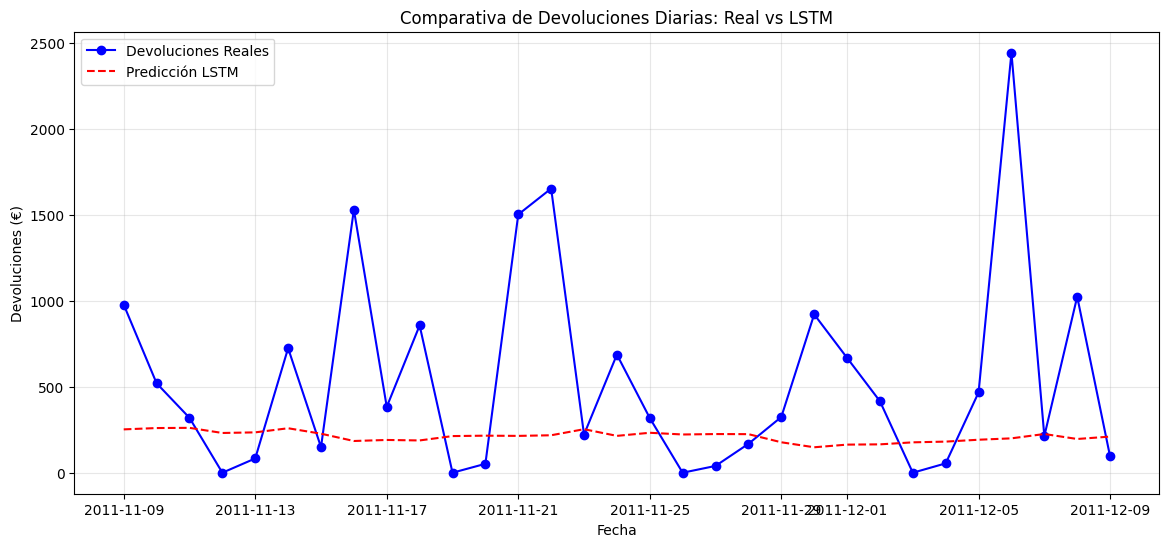

In [9]:
print("--- PASO 3: ENTRENAMIENTO LSTM ---")
model = Sequential()
model.add(LSTM(32, input_shape=(LOOKBACK, 1)))
model.add(Dropout(0.1))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

start_time = time.time()
print("\nEntrenando modelo LSTM...")
history = model.fit(X_train, y_train, epochs=60, batch_size=16, validation_split=0.1,
                    callbacks=[early_stop, reduce_lr], shuffle=False, verbose=0)
print(f"Entrenamiento completado en {time.time() - start_time:.2f} segundos")

print("\n--- PASO 4: PREDICCIÓN E INVERSIÓN ---")
preds_scaled = model.predict(X_test, verbose=0)

# Inversión de Escala
preds_unscaled_log = scaler.inverse_transform(preds_scaled)
y_test_unscaled_log = scaler.inverse_transform(y_test.reshape(-1, 1))

# Inversión de logaritmo
preds_real = np.expm1(preds_unscaled_log).flatten()
y_real = np.expm1(y_test_unscaled_log).flatten()
dates_test = df_test['date'].iloc[idx_test].values

print("\n--- PASO 5: EVALUACIÓN Y MÉTRICAS FINALES ---")
mae = mean_absolute_error(y_real, preds_real)
rmse = np.sqrt(mean_squared_error(y_real, preds_real))
r2 = r2_score(y_real, preds_real)

print("="*45)
print("        RESULTADOS LSTM DEVOLUCIONES       ")
print("="*45)
print(f"MAE:  € {mae:,.2f}")
print(f"RMSE: € {rmse:,.2f}")
print(f"R2:   {r2:.4f}")
print("="*45)
print(f"[Info] Total de días evaluados en test: {len(y_real)}\n")

# Gráfico
plt.figure(figsize=(14,6))
plt.plot(dates_test, y_real, label="Devoluciones Reales", color='blue', marker='o')
plt.plot(dates_test, preds_real, label="Predicción LSTM", color='red', linestyle='--')
plt.title("Comparativa de Devoluciones Diarias: Real vs LSTM")
plt.xlabel("Fecha")
plt.ylabel("Devoluciones (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*80)
print(" FASE FINAL: GENERACIÓN DE DATAFRAMES ")
print("="*80)

# Exportación CSV
df_eval_corregido = pd.DataFrame({
    'Fecha': dates_test,
    'Devoluciones_Reales': y_real,
    'Prediccion_LSTM': preds_real
})
ruta_drive = '/content/drive/MyDrive/TFM_Prediccion_Devoluciones_LSTM_Corregido.csv'
df_eval_corregido.to_csv(ruta_drive, index=False)
print(f"Archivo exportado correctamente en:\n{ruta_drive}")


 FASE FINAL: GENERACIÓN DE DATAFRAMES 
Archivo exportado correctamente en:
/content/drive/MyDrive/TFM_Prediccion_Devoluciones_LSTM_Corregido.csv
